# ARX / ARMAX — Per-Motor Current Prediction (Power Limiter)

| Model | Type | Key property |
|-------|------|-------------|
| **ARX** | Linear AR + exogenous | Fast, interpretable, trivial C port |
| **ARMAX** | ARX + moving-average residuals | Handles correlated noise |

**Data:** `training_data.csv` — 5 Hz, split by run_id.
**Output:** I_FL, I_FR, I_RL, I_RR at t+1 (multi-output Ridge regression).

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path().resolve()
SRC_DIR  = _cwd if (_cwd / 'functions').exists() else _cwd / 'src'
DATA_DIR = SRC_DIR.parent / 'data' / 'model'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DT            = 0.2        # 5 Hz sample rate
N_LAGS        = 5          # 1 s lookback (5 ticks × 0.2 s)
POWER_LIMIT_W = 80_000
MOTOR_NAMES   = ['FL', 'FR', 'RL', 'RR']
from functions.arx       import ARXModel
from functions.armax     import ARMAXModel
from functions.evaluation import display_model_results, compare_models

N_MA = 3   # ARMAX moving-average order
print(f'DATA_DIR : {DATA_DIR}')


DATA_DIR : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model


## 1. Data Loading and Feature Engineering

In [2]:
df = pd.read_csv(DATA_DIR / 'training_data.csv')
df = df.sort_values(['run_id', 'timestamp_s']).reset_index(drop=True)
df['T_sum'] = df['T_FL'] + df['T_FR'] + df['T_RL'] + df['T_RR']

# Run-safe lag features (no cross-run leakage)
for m in MOTOR_NAMES:
    for lag in range(1, N_LAGS + 1):
        df[f'I_{m}_lag{lag}'] = df.groupby('run_id')[f'I_{m}'].shift(lag)
for lag in range(1, N_LAGS + 1):
    df[f'T_sum_lag{lag}'] = df.groupby('run_id')['T_sum'].shift(lag)

# 1-step-ahead target (within each run)
for m in MOTOR_NAMES:
    df[f'I_{m}_next'] = df.groupby('run_id')[f'I_{m}'].shift(-1)

df_clean = df.dropna().reset_index(drop=True)
print(f'Loaded  : {len(df):,} rows, {df["run_id"].nunique()} runs')
print(f'Clean   : {len(df_clean):,} rows after dropna')


Loaded  : 5,693 rows, 10 runs
Clean   : 5,633 rows after dropna


In [3]:
runs         = sorted(df_clean['run_id'].unique())
n_train_runs = max(1, int(len(runs) * 0.70))
train_runs   = runs[:n_train_runs]
test_runs    = runs[n_train_runs:]

df_train = df_clean[df_clean['run_id'].isin(train_runs)].reset_index(drop=True)
df_test  = df_clean[df_clean['run_id'].isin(test_runs)].reset_index(drop=True)

y_train = df_train[[f'I_{m}_next' for m in MOTOR_NAMES]].values   # (n, 4)
y_test  = df_test[[f'I_{m}_next'  for m in MOTOR_NAMES]].values
U_test  = df_test['U_dc'].values
t_test  = df_test['timestamp_s'].values

print(f'Train runs : {train_runs}  ({len(df_train):,} samples)')
print(f'Test  runs : {test_runs}   ({len(df_test):,} samples)')
print(f'y_train    : {y_train.shape}')


Train runs : [2, 3, 4, 5, 6, 7, 8]  (3,730 samples)
Test  runs : [9, 10, 11]   (1,903 samples)
y_train    : (3730, 4)


In [4]:
# Shared feature matrix for all 4 motors
feature_cols = []
for m in MOTOR_NAMES:
    feature_cols.append(f'I_{m}')           # current value at t
    for lag in range(1, N_LAGS + 1):
        feature_cols.append(f'I_{m}_lag{lag}')
feature_cols.append('T_sum')
for lag in range(1, N_LAGS + 1):
    feature_cols.append(f'T_sum_lag{lag}')
feature_cols.append('U_dc')

X_train = df_train[feature_cols].values
X_test  = df_test[feature_cols].values
print(f'Features : {len(feature_cols)}   X_train: {X_train.shape}')


Features : 31   X_train: (3730, 31)


## 2. ARX — AutoRegressive eXogenous

```
I_m(t+1) = a1*I_m(t) + ... + a5*I_m(t-4)
         + b1*T_sum(t) + ... + b5*T_sum(t-4)
         + c*U_dc(t) + bias
```
Fitted jointly for all 4 motors via Ridge regression (y is 2D: n_samples x 4).

ARX train  : 2.4 ms
ARX infer  : 0.31 ms  (1903 samples)
Coef shape : (4, 31)  (n_outputs x n_features)
  MODEL: ARX (Ridge)
  R2              : 0.5692
  RMSE            : 5815.81 A
  MAE             : 2364.08 A
  MedAE           : 366.78 A
  MAPE            : 85.11 %
  R2 per motor    : FL=0.582  FR=0.576  RL=0.541  RR=0.579
--------------------------------------------------------
  Under-pred.     : 27.7 % of samples
  Mean under-pred.: 4094.13 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 11323.44 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 20   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 98.9 %
--------------------------------------------------------
  Time/sample     : 0.0002 ms
  Frequency       : 6077037.6 Hz



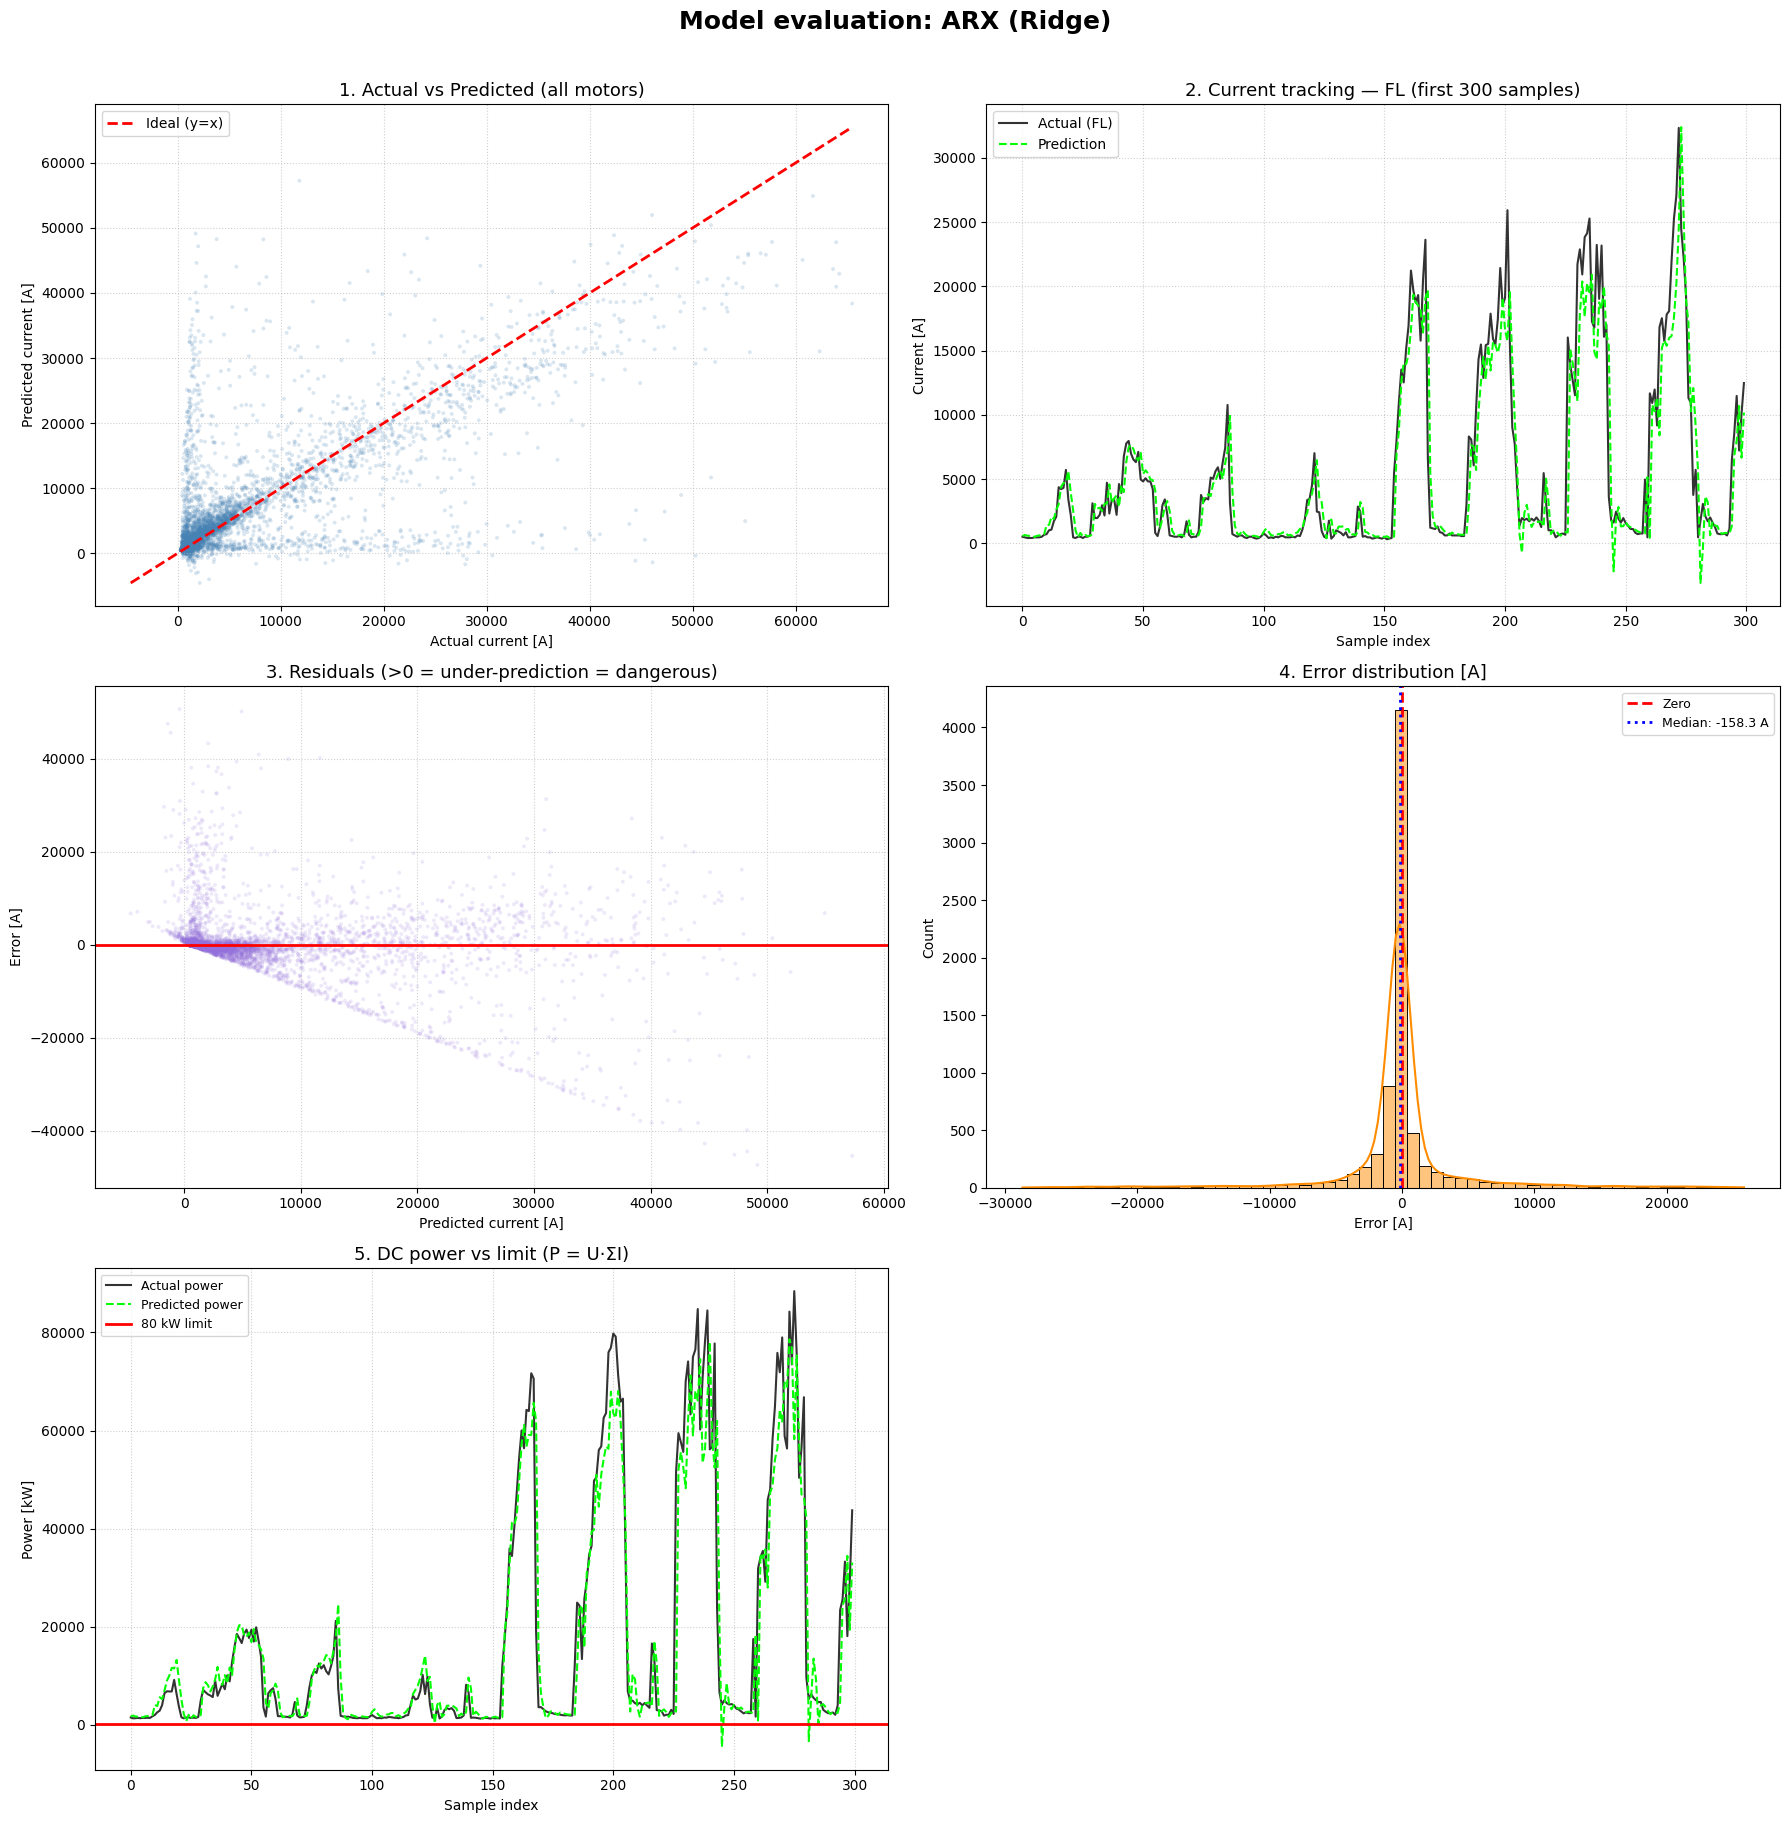

In [5]:
arx = ARXModel(alpha=1.0)

t0 = time.perf_counter()
arx.fit(X_train, y_train)
t_train_arx = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_arx = arx.predict(X_test)
t_infer_arx = time.perf_counter() - t0

print(f'ARX train  : {t_train_arx*1000:.1f} ms')
print(f'ARX infer  : {t_infer_arx*1000:.2f} ms  ({len(X_test)} samples)')
print(f'Coef shape : {arx.coef_.shape}  (n_outputs x n_features)')

m_arx = display_model_results(
    'ARX (Ridge)', y_test, y_pred_arx, t_infer_arx,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=False,
)


## 3. ARMAX — ARX + Moving Average

Adds lagged residuals as features to capture correlated noise:
```
I_m(t+1) = ARX(t) + c1*e_m(t) + c2*e_m(t-1) + ... + bias
```
Two-pass fit: (1) fit ARX, compute residuals; (2) append lagged residuals, refit.

ARMAX train : 24.1 ms  (4 motors)
ARMAX infer : 442.33 ms  y_pred: (1903, 4)
  MODEL: ARMAX (Ridge)
  R2              : 0.4746
  RMSE            : 6422.52 A
  MAE             : 2689.19 A
  MedAE           : 514.43 A
  MAPE            : 106.00 %
  R2 per motor    : FL=0.619  FR=0.517  RL=0.333  RR=0.585
--------------------------------------------------------
  Under-pred.     : 31.1 % of samples
  Mean under-pred.: 4198.83 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 11636.96 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 69   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 96.4 %
--------------------------------------------------------
  Time/sample     : 0.2324 ms
  Frequency       : 4302.2 Hz



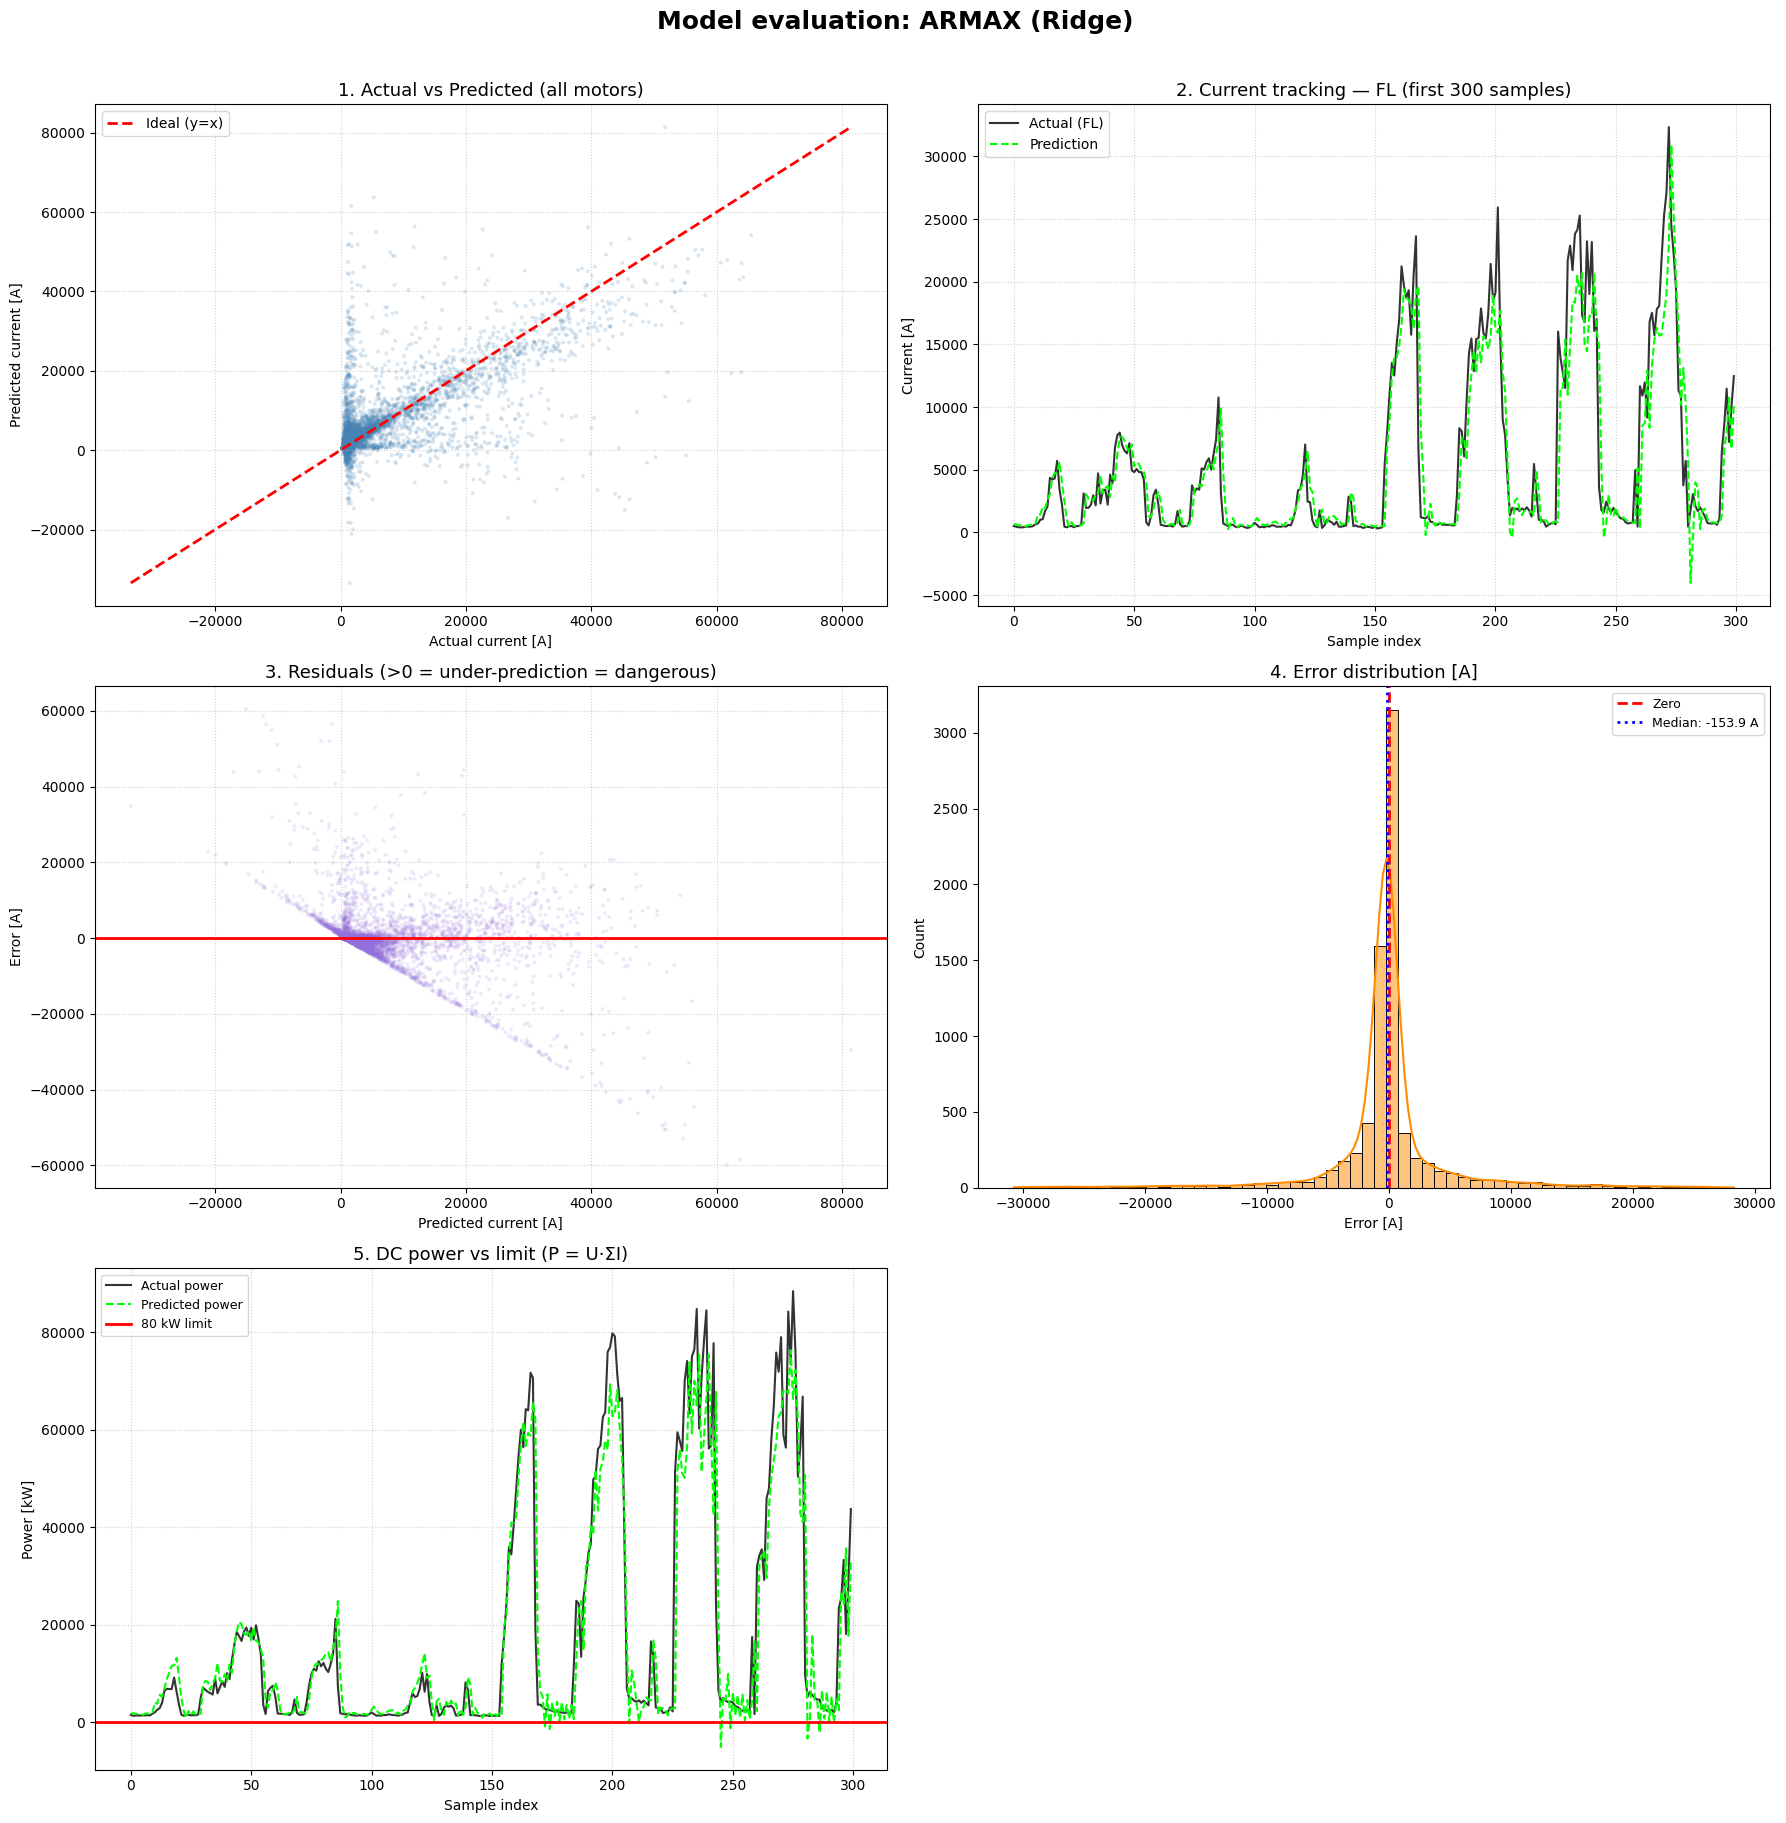

In [6]:
# ARMAX.predict is single-output — train 4 independent models (one per motor)
armax_models = {}
t0 = time.perf_counter()
for j, m in enumerate(MOTOR_NAMES):
    armax_m = ARMAXModel(n_ma=N_MA, alpha=1.0)
    armax_m.fit(X_train, y_train[:, j])
    armax_models[m] = armax_m
t_train_armax = time.perf_counter() - t0
print(f'ARMAX train : {t_train_armax*1000:.1f} ms  (4 motors)')

t0 = time.perf_counter()
y_pred_armax = np.column_stack([
    armax_models[m].predict(X_test, y_true=y_test[:, j])
    for j, m in enumerate(MOTOR_NAMES)
])
t_infer_armax = time.perf_counter() - t0
print(f'ARMAX infer : {t_infer_armax*1000:.2f} ms  y_pred: {y_pred_armax.shape}')

m_armax = display_model_results(
    'ARMAX (Ridge)', y_test, y_pred_armax, t_infer_armax,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=False,
)


## 4. Visualization

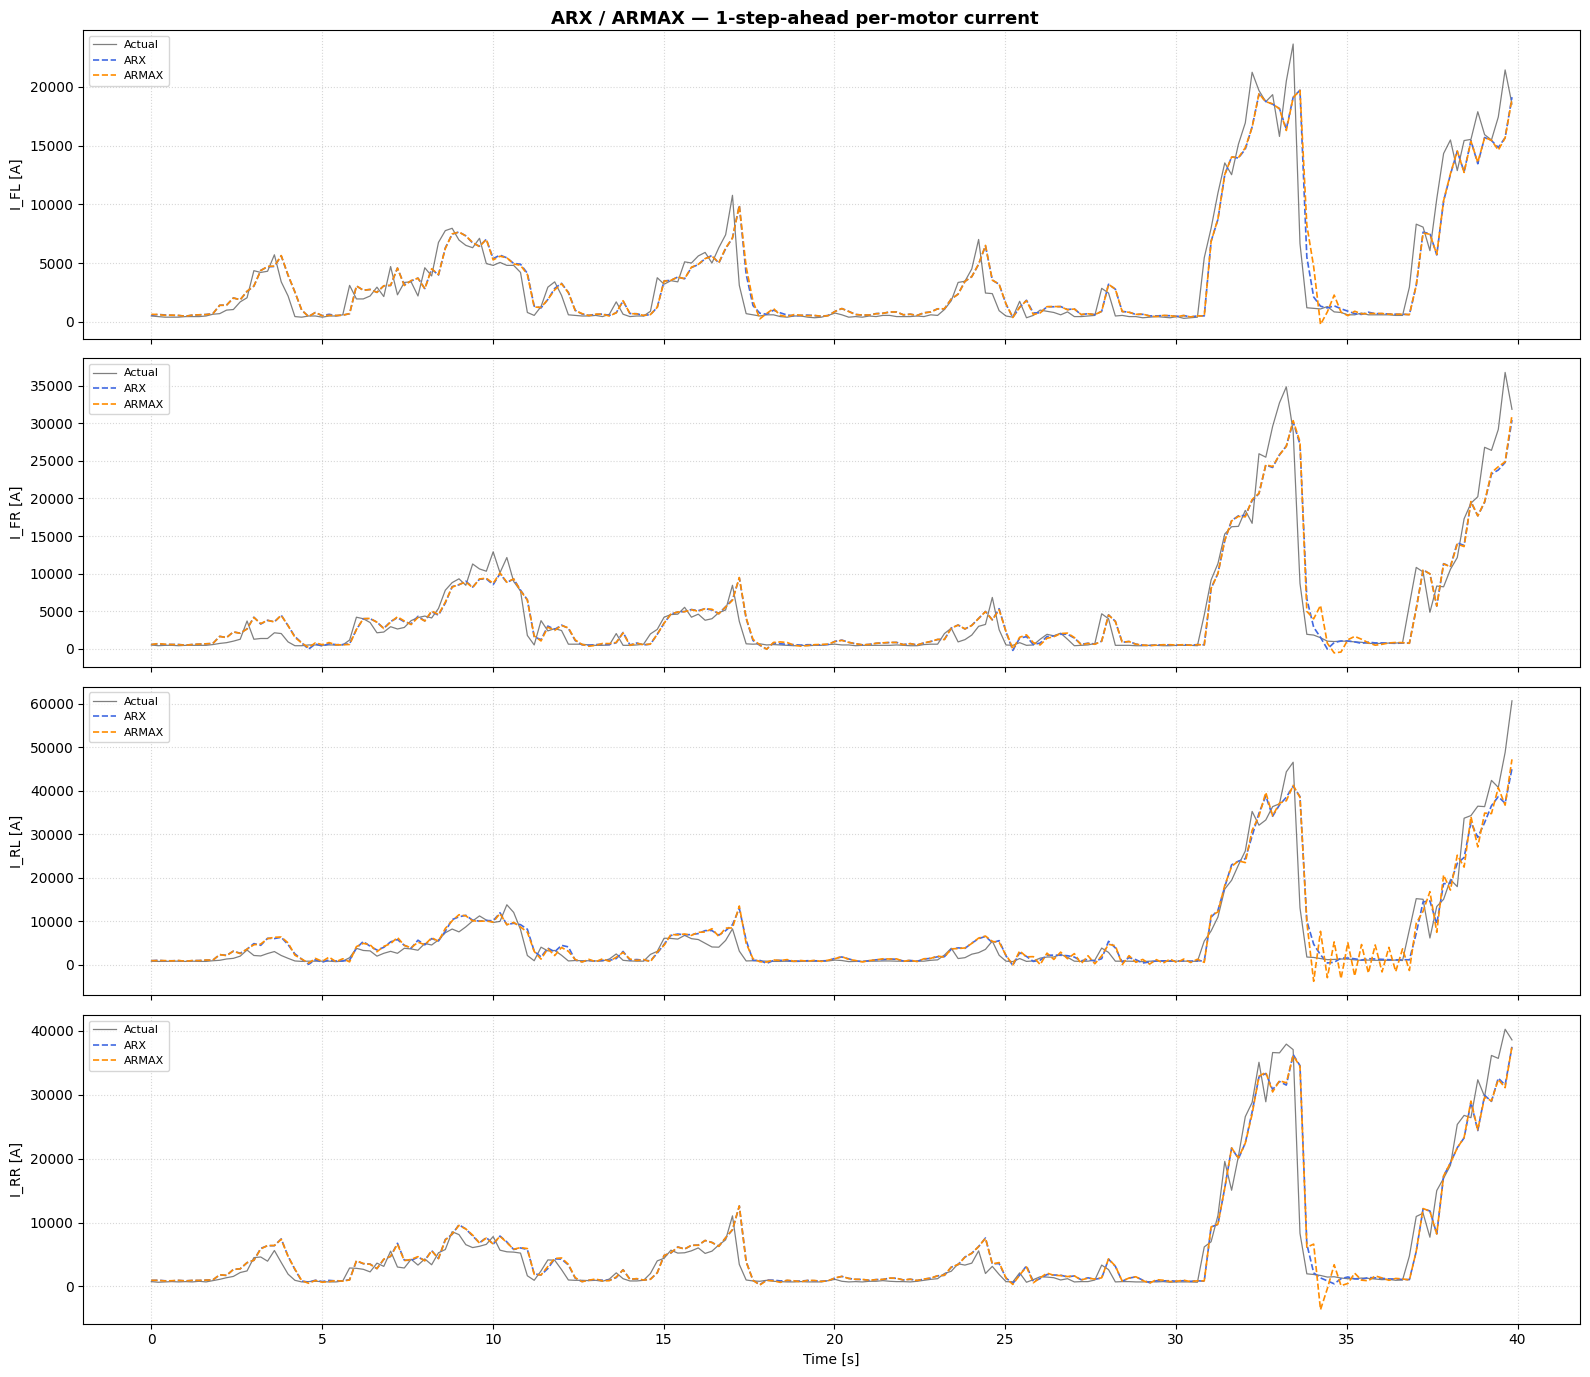

In [7]:
N_PLOT = min(200, len(y_test))
sl     = slice(0, N_PLOT)
t_pl   = t_test[sl] - t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('ARX / ARMAX — 1-step-ahead per-motor current', fontsize=13, fontweight='bold')
for i, (ax, m) in enumerate(zip(axes, MOTOR_NAMES)):
    ax.plot(t_pl, y_test[sl, i],       lw=0.9, color='black',     alpha=0.5, label='Actual')
    ax.plot(t_pl, y_pred_arx[sl, i],   lw=1.2, color='royalblue', ls='--',   label='ARX')
    ax.plot(t_pl, y_pred_armax[sl, i], lw=1.2, color='darkorange',ls='--',   label='ARMAX')
    ax.set_ylabel(f'I_{m} [A]'); ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.5)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()


## 6. ARX Conservative — Quantile Regression (q = 0.90)

Replacing Ridge with `QuantileRegressor(quantile=0.90)` shifts each prediction to the
90th percentile of the conditional distribution → model over-predicts current →
**fewer False Negatives** (missed power violations).

Trade-off: higher RMSE, but safety-critical FN drops significantly.

Training ARX Q=0.90 (4 x QuantileRegressor) ...
Train : 3210 ms  |  Infer : 1.993 ms  |  shape: (1903, 4)
  MODEL: ARX Conservative (Q=0.90)
  R2              : 0.3687
  RMSE            : 7039.88 A
  MAE             : 2917.29 A
  MedAE           : 497.28 A
  MAPE            : 111.02 %
  R2 per motor    : FL=0.358  FR=0.409  RL=0.338  RR=0.358
--------------------------------------------------------
  Under-pred.     : 14.2 % of samples
  Mean under-pred.: 5001.43 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 13739.77 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 1   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 99.9 %
--------------------------------------------------------
  Time/sample     : 0.0010 ms
  Frequency       : 954640.3 Hz



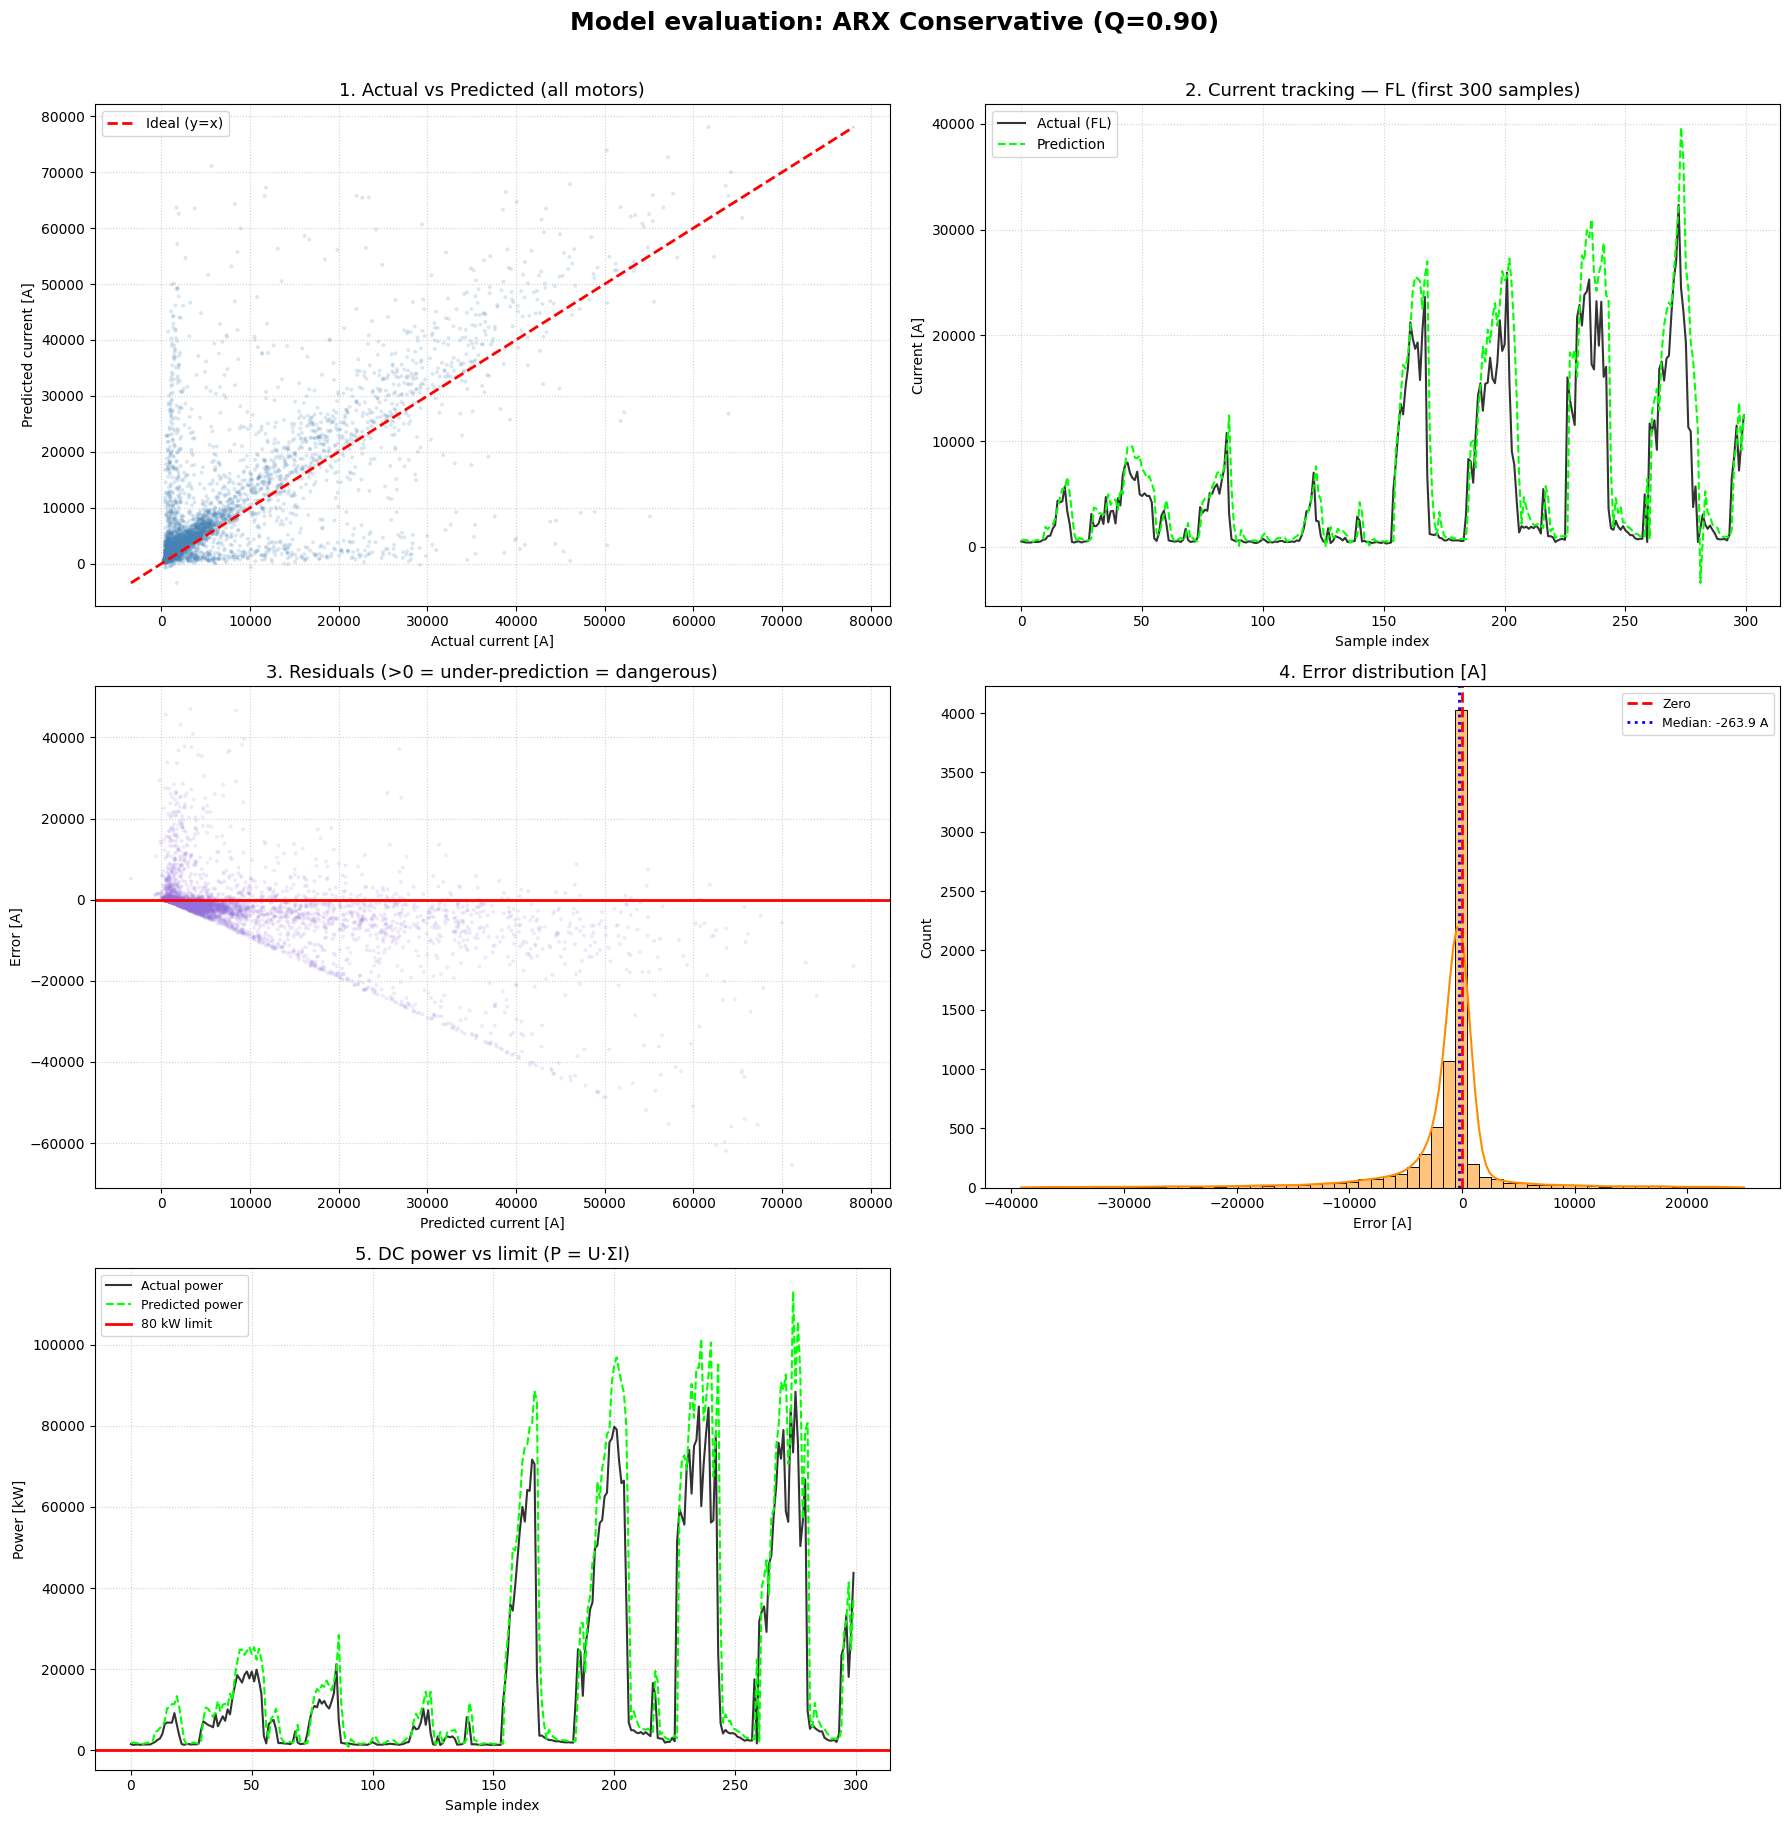

In [8]:
from functions.arx import ARXModel

arx_q = ARXModel(alpha=1.0, quantile=0.90)

print('Training ARX Q=0.90 (4 x QuantileRegressor) ...')
t0 = time.perf_counter()
arx_q.fit(X_train, y_train)     # fits 4 single-output QuantileRegressors internally
t_train_arxq = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_arx_q = arx_q.predict(X_test)
t_infer_arxq = time.perf_counter() - t0

print(f'Train : {t_train_arxq*1000:.0f} ms  |  Infer : {t_infer_arxq*1000:.3f} ms  |  shape: {y_pred_arx_q.shape}')

m_arx_q = display_model_results(
    'ARX Conservative (Q=0.90)', y_test, y_pred_arx_q, t_infer_arxq,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=False,
)


### Visualisation — ARX vs ARX-Q=0.90

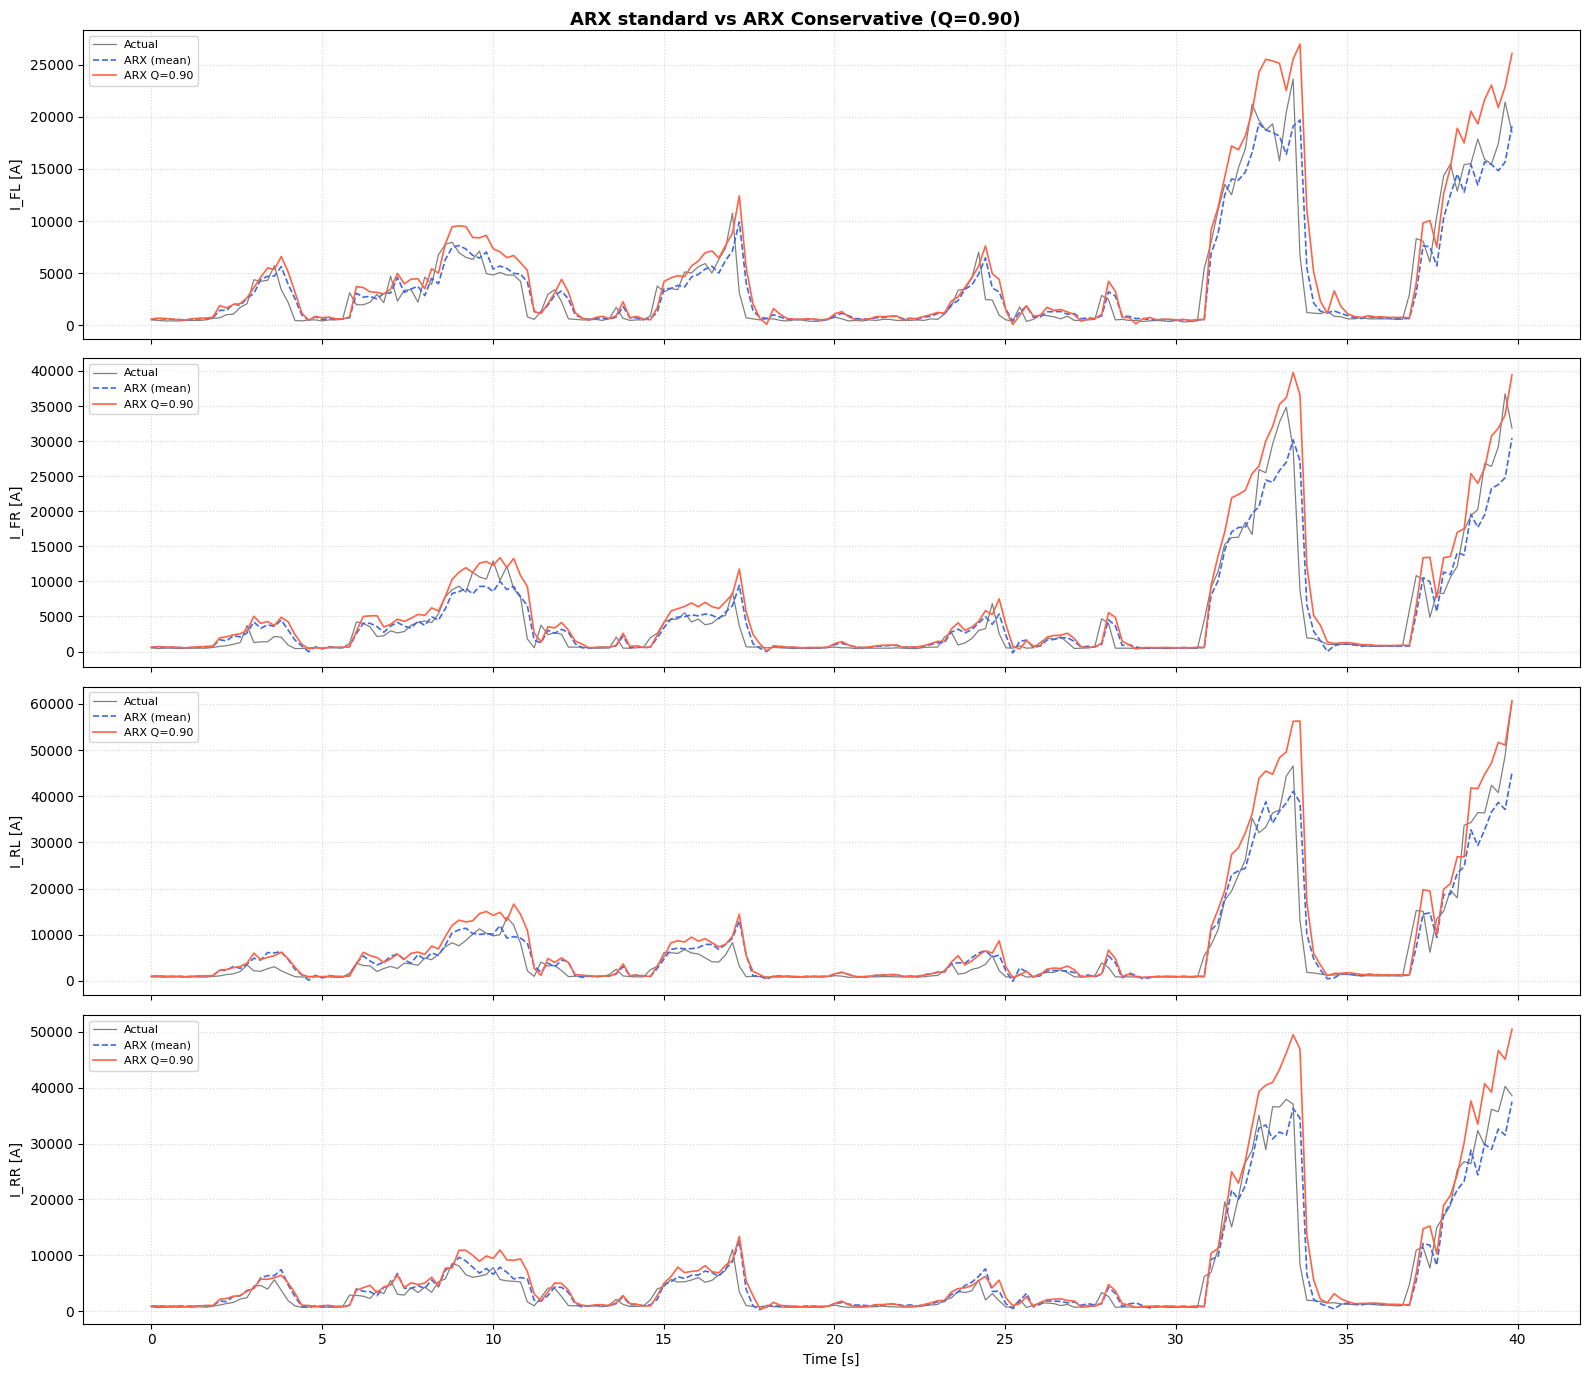

In [9]:
N_PLOT = min(200, len(y_test))
sl     = slice(0, N_PLOT)
t_pl   = t_test[sl] - t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('ARX standard vs ARX Conservative (Q=0.90)', fontsize=13, fontweight='bold')
for i, (ax, m) in enumerate(zip(axes, MOTOR_NAMES)):
    ax.plot(t_pl, y_test[sl, i],         lw=0.9, color='black',      alpha=0.5, label='Actual')
    ax.plot(t_pl, y_pred_arx[sl, i],     lw=1.2, color='royalblue',  ls='--',   label='ARX (mean)')
    ax.plot(t_pl, y_pred_arx_q[sl, i],   lw=1.2, color='tomato',     ls='-',    label='ARX Q=0.90')
    ax.set_ylabel(f'I_{m} [A]'); ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.5)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()


## 7. Full Model Comparison


  MODEL COMPARISON
                             R2  RMSE [A]  MAE [A]  MedAE [A]  MAPE [%]  Underpred. [%]  Mean underpred. [A]  ms/sample  Freq. [Hz]  R2_FL  R2_FR  R2_RL  R2_RR  Power RMSE [kW]  Violations [n]  FN (missed)  FP (unnecessary)  Violation recall [%]
model                                                                                                                                                                                                                                                
ARX (Ridge)               0.569  5815.809 2364.080    366.781    85.106          27.733             4094.133      0.000 6077037.551  0.582  0.576  0.541  0.579        11323.444            1903           20                 0                98.949
ARX Conservative (Q=0.90) 0.369  7039.877 2917.285    497.284   111.023          14.162             5001.428      0.001  954640.289  0.358  0.409  0.338  0.358        13739.767            1903            1                 0                99.

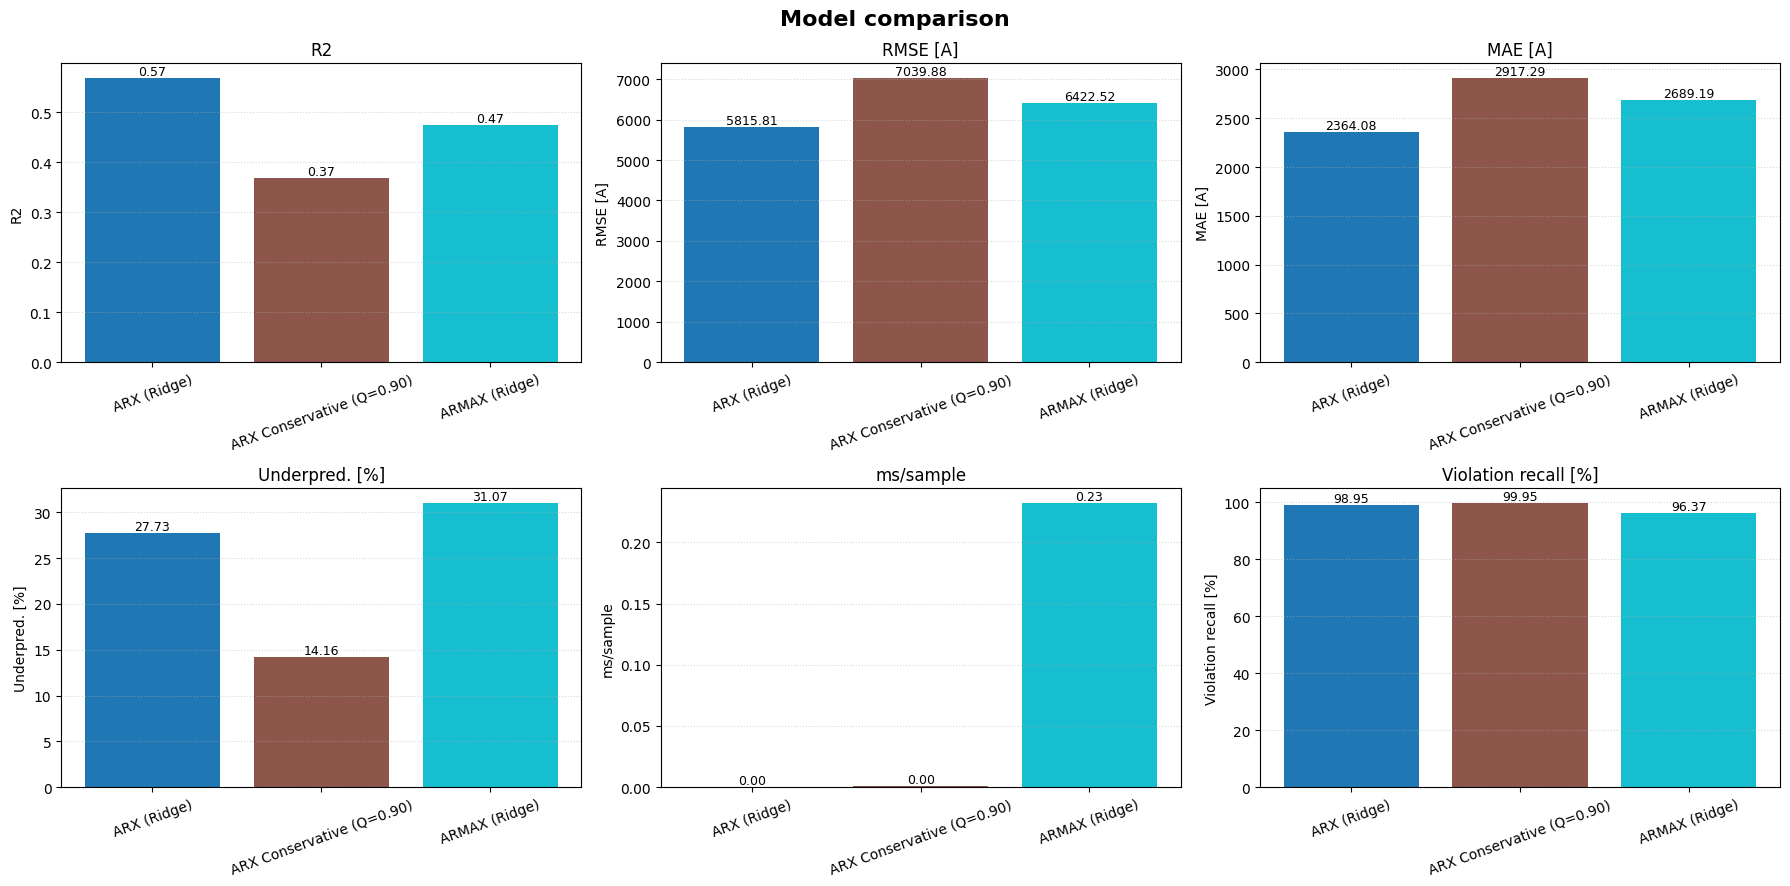

,R2,RMSE [A],MAE [A],MedAE [A],MAPE [%],Underpred. [%],Mean underpred. [A],ms/sample,Freq. [Hz],R2_FL,R2_FR,R2_RL,R2_RR,Power RMSE [kW],Violations [n],FN (missed),FP (unnecessary),Violation recall [%]
model,,,,,,,,,,,,,,,,,,
ARX (Ridge),0.569173,5815.808735,2364.079606,366.780711,85.106172,27.732528,4094.132637,0.000165,6.077038e+06,0.581859,0.576157,0.540697,0.579424,11323.443761,1903,20,0,98.949028
ARX Conservative (Q=0.90),0.368733,7039.877464,2917.285156,497.283839,111.022877,14.161850,5001.427680,0.001048,9.546403e+05,0.358306,0.409485,0.337967,0.357969,13739.766737,1903,1,0,99.947451
ARMAX (Ridge),0.474596,6422.519197,2689.191254,514.427712,106.003502,31.069364,4198.829043,0.232441,4.302173e+03,0.619281,0.517170,0.332703,0.585228,11636.957015,1903,69,0,96.374146


In [10]:
compare_models([m_arx, m_arx_q, m_armax], sort_by='FN')